In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.chdir('../')
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [3]:
import torch
from torch import nn

from transformers import AutoConfig, AutoTokenizer
from safetensors.torch import load_file
from pathlib import Path
import json

from run_gradmemgpt_on_kv_retrieval import ExperimentArgs as GradMemArgs
from grad_memgpt import GradMemGPT, GradMemGPTConfig

def prepare_gradmem_model(run_path):
    # get best saved checkpoint
    best_score = -1
    best_cpt = None
    for cpt_path in Path(run_path).glob('**/checkpoint-*'):
        cpt_state = json.load(open(f'{cpt_path}/trainer_state.json'))
        cur_score = cpt_state['log_history'][-1]['eval_token_accuracy']
        if cur_score > best_score:
            best_score = cur_score
            best_cpt = str(cpt_path)

    # load args for original experiment
    CPT_PATH = f"{best_cpt}/model.safetensors"
    cli_config = json.load(open(f'{run_path}/config.json'))['cli_args']
    cli_config['init_checkpoint'] = CPT_PATH
    if 'init_base_checkpoint' in cli_config:
        cli_config.pop('init_base_checkpoint')
    if 'last_K_second_order' in cli_config:
        cli_config.pop('last_K_second_order')
    if 'learn_lr' in cli_config:
        cli_config.pop('learn_lr')
    if 'context_parallel_chunk_size' in cli_config:
        cli_config.pop('context_parallel_chunk_size')

    args = GradMemArgs(**cli_config)

    # load/create backbone
    if args.pretrained_model is None:
        # create tokenizer
        tokenizer = AutoTokenizer.from_pretrained(args.tokenizer_path)
        # create base model config
        if args.base_model == 'gpt2':
            config = AutoConfig.from_pretrained('gpt2')
            config.n_layer = args.n_layer
            config.n_head = args.n_head
            config.n_embd = args.n_embd
        elif args.base_model == 'pythia':
            config = AutoConfig.from_pretrained('EleutherAI/pythia-160m')
            config.num_hidden_layers = args.n_layer
            config.num_attention_heads = args.n_head
            config.hidden_size = args.n_embd
            config.intermediate_size = config.hidden_size * 4
        elif args.base_model == 'llama':
            # config = AutoConfig.from_pretrained('meta-llama/Llama-3.2-1B')
            config = AutoConfig.from_pretrained('unsloth/Llama-3.2-1B')
            config.num_hidden_layers = args.n_layer
            config.num_attention_heads = args.n_head
            config.num_key_value_heads = args.n_head
            config.hidden_size = args.n_embd
            config.head_dim = config.hidden_size // config.num_attention_heads
            config.intermediate_size = config.hidden_size * 4
        else:
            raise ValueError(f'Unsupported base model: {args.base_model}')
        
        config.torch_dtype = "float32"  # weights in float32, at training precision is controlled by accelerate
        config.vocab_size = tokenizer.vocab_size
        config.pad_token_id = tokenizer.pad_token_id
        config.bos_token_id = tokenizer.bos_token_id
        config.eos_token_id = tokenizer.eos_token_id
        config.use_cache = False

    else:
        config = None
        tokenizer = AutoTokenizer.from_pretrained(args.pretrained_model)
        if tokenizer.pad_token_id is None:
            tokenizer.pad_token_id = tokenizer.eos_token_id

    # initialize GradRMT model
    gradmem_config = GradMemGPTConfig(pretrained_model=args.pretrained_model, base_config=config,
                                      memory_backend=args.memory_backend,
                                      n_mem_tokens=args.n_mem_tokens, K=args.K,
                                      last_K_second_order=args.last_K_second_order,
                                      lr=args.inner_lr, use_adam=args.use_adam, grad_mode=args.grad_mode,
                                      n_ctrl_tokens=args.n_ctrl_tokens,
                                      inner_clip_value=args.inner_clip_value, inner_clip_norm=args.inner_clip_norm,
                                      use_mem_proj=args.use_mem_proj, mem_proj_mode=args.mem_proj_mode,
                                      use_write_head=args.use_write_head,
                                      use_write_lora=args.use_write_lora,
                                      write_lora_r=args.write_lora_r,
                                      write_lora_alpha=args.write_lora_alpha,
                                      write_lora_dropout=args.write_lora_dropout,
                                      write_lora_target_modules=args.write_lora_target_modules,
                                      lora_mem_placement=args.lora_mem_placement,
                                      lora_mem_r=args.lora_mem_r,
                                      lora_mem_alpha=args.lora_mem_alpha,
                                      lora_mem_dropout=args.lora_mem_dropout,
                                      lora_mem_layers=args.lora_mem_layers,
                                      lora_mem_target_modules=args.lora_mem_target_modules,
                                      kv_mem_layers=args.kv_mem_layers,
                                      freeze_backbone=args.freeze_backbone,
                                      use_gradient_checkpointing=args.use_gradient_checkpointing,
                                      attn_implementation=args.attn_implementation,
                                      write_objective=args.write_objective,
                                      energy_head_hidden_dim=args.energy_head_hidden_dim,
                                      use_layerwise_energy=args.use_layerwise_energy,
                                      write_reconstruction_weight=args.write_reconstruction_weight,
                                      write_energy_weight=args.write_energy_weight,
                                      energy_rank_weight=args.energy_rank_weight,
                                      energy_traj_weight=args.energy_traj_weight,
                                      energy_margin=args.energy_margin,
                                      energy_traj_margin=args.energy_traj_margin,
                                      energy_rank_temperature=args.energy_rank_temperature,
                                      energy_mix_alpha=args.energy_mix_alpha,
                                      energy_anchor_weight=args.energy_anchor_weight,
                                      add_inner_loss_to_outer=args.add_inner_loss_to_outer,
                                       inner_loss_weight=args.inner_loss_weight,
                                        memory_alignment_weight=args.memory_alignment_weight,
                                        step_alignment_weight=args.step_alignment_weight,
                                       grad_align_norm=args.grad_align_norm,
                                        intermediate_read_weight=args.intermediate_read_weight,
                                       orthogonal_loss_weight=args.orthogonal_loss_weight,
                                       ivan_loss_weight=args.ivan_loss_weight)

    # Create gradmemgpt model
    model = GradMemGPT(gradmem_config)

    # load existing checkpoint
    model_to_init_from_ckpt = None
    if args.init_checkpoint is not None:
        model_to_init_from_ckpt = model
        init_ckpt_path = args.init_checkpoint
        print(args.init_checkpoint)

        print(f'loading checkpoint from {init_ckpt_path}')
        missing_k, unexpected_k = model_to_init_from_ckpt.load_state_dict(load_file(init_ckpt_path), strict=False)
        if len(missing_k) != 0:
            print(f'{missing_k} were not loaded from checkpoint! These parameters were randomly initialized.')
        if len(unexpected_k) != 0:
            print(f'{unexpected_k} were found in checkpoint, but model_to_init_from_ckpt is not expecting them!')
    
    # model.to(torch.bfloat16)
    model.eval()
    model.to('cuda')
    model.model.tie_weights()

    return model, tokenizer, args

/data/home/mkairov/miniforge3/envs/rmt/lib/python3.13/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.sparse import csr_matrix, issparse
2026-08-10 16:45:38,840 - root - INFO - CUDA DEVICE COUNT: 1


In [4]:
def collate_fn(batch, tokenizer):
    # context = [item['context'] for item in batch]
    context = batch['context']
    query = [q + t for q, t in zip(batch['query'], batch['target'])]
    # query = [item['query'] + item['target'] for item in batch]

    context_input_ids = tokenizer(context, return_tensors="pt", add_special_tokens=True,
                                  padding=True, pad_to_multiple_of=8).input_ids
    query_encoded = tokenizer(query, return_tensors="pt", add_special_tokens=True,
                              padding=True, pad_to_multiple_of=8, return_offsets_mapping=True)
    query_input_ids = query_encoded['input_ids']
    offsets_mapping = query_encoded['offset_mapping']

    # add labels_mask
    # input_seq: 0, target_seq: 1, seq = input_seq + target_seq
    labels_mask = torch.zeros_like(query_input_ids)
    for i in range(len(context)):
        query_seq_len = len(batch['query'][i])
        target_seq_len = len(batch['target'][i])
        target_st, target_end = query_seq_len, query_seq_len + target_seq_len
        # find target tokens
        # since target is closer to the end (context, query, target), search from the end
        in_target = False
        for j in range(len(offsets_mapping[i]) - 1, -1, -1):
            st, end = offsets_mapping[i][j]
            # if (target_st, target_end) intersects with (st, end), it is a target token
            if st < target_end and end > target_st:
                labels_mask[i, j] = 1
                in_target = True
            elif in_target:
                break

    labels = query_input_ids * labels_mask + (1 - labels_mask) * -100
    input_ids = {
        'context_input_ids': context_input_ids.cuda(),
        'query_input_ids': query_input_ids.cuda()
    }
    return input_ids, labels

In [5]:
def tree_map(fn, x):
    if torch.is_tensor(x):
        return fn(x)
    if isinstance(x, dict):
        return {k: tree_map(fn, v) for k, v in x.items()}
    if isinstance(x, tuple):
        return tuple(tree_map(fn, v) for v in x)
    if isinstance(x, list):
        return [tree_map(fn, v) for v in x]
    print(x)
    raise TypeError(f"Unsupported memory leaf: {type(x)}")

def tree_map2(fn, a, b):
    if torch.is_tensor(a):
        return fn(a, b)
    if isinstance(a, dict):
        return {k: tree_map2(fn, a[k], b[k]) for k in a}
    if isinstance(a, tuple):
        return tuple(tree_map2(fn, x, y) for x, y in zip(a, b))
    if isinstance(a, list):
        return [tree_map2(fn, x, y) for x, y in zip(a, b)]
    raise TypeError(f"Unsupported memory leaf: {type(a)}")

def tree_add(a, b):
    return tree_map2(lambda x, y: x + y, a, b)

def tree_sub(a, b):
    return tree_map2(lambda x, y: x - y, a, b)

def tree_scale(a, s):
    return tree_map(lambda x: x * s, a)

def tree_dot(a, b):
    total = None
    def collect(x, y):
        nonlocal total
        v = (x * y).sum()
        total = v if total is None else total + v
        return x

    tree_map2(collect, a, b)
    return total

def tree_norm(a):
    return tree_dot(a, a).sqrt()

def tree_detach_clone(a):
    return tree_map(lambda x: x.detach().clone(), a)

In [6]:
import torch.nn.functional as F

def compute_kv_write_losses(model, write_batch, outs, logits=None, kv_start_offset=0):
    """
    Computes average inner-objective loss on KV key/value tokens.
    KV format: |kk:vv|
    1-indexed positions:
      keys   = 2,3
      values = 5,6
    Args:
      model: GradMemGPT instance.
      write_batch: batch produced by backend.build_write_inputs(...).
      outs: model/backbone output from the write forward pass.
      logits: optional reconstruction logits already sliced to write_batch["logits_start"].
      kv_start_offset: 0 if context starts with |kk:vv|, 1 if there is leading BOS.
    Returns:
      key_loss, value_loss: scalar tensors averaged over all key/value tokens in batch.
    """
    write_objective = model.write_objective
    needs_rec = write_objective in ("reconstruction", "energy_with_reconstruction")
    needs_energy = write_objective in ("energy", "energy_with_reconstruction")
    label_shift = write_batch.get("label_shift", 0)
    labels_loss = write_batch["lm_labels"][:, label_shift:]
    mask_loss = write_batch["mask"][:, label_shift:].bool()
    token_inner_loss = None
    if needs_rec:
        if logits is None:
            hidden = outs.last_hidden_state[:, write_batch["logits_start"]:, :]
            if model.use_write_head:
                logits = model.write_head(hidden)
            else:
                output_embeddings = model.model.get_output_embeddings()
                logits = output_embeddings(hidden)
        logits_loss = logits[:, :-1]
        if logits_loss.size(1) != labels_loss.size(1):
            raise ValueError(
                f"reconstruction alignment mismatch: logits={logits_loss.size(1)}, "
                f"labels={labels_loss.size(1)}, label_shift={label_shift}"
            )
        rec_token_loss = F.cross_entropy(
            logits_loss.reshape(-1, logits.size(-1)),
            labels_loss.reshape(-1),
            ignore_index=-100,
            reduction="none",
        ).view(logits.size(0), -1)
        token_inner_loss = model.write_reconstruction_weight * rec_token_loss
    if needs_energy:
        context_hidden = outs.last_hidden_state[:, write_batch["context_start"]:, :]
        context_mask = write_batch["mask"].to(device=context_hidden.device).bool()
        if context_hidden.size(1) != context_mask.size(1):
            raise ValueError(
                f"energy alignment mismatch: hidden={context_hidden.size(1)}, "
                f"mask={context_mask.size(1)}"
            )
        energy_token_loss = model.energy_head(model.energy_ln(context_hidden)).squeeze(-1)
        energy_token_loss = energy_token_loss[:, label_shift:]
        if energy_token_loss.size(1) != labels_loss.size(1):
            raise ValueError(
                f"energy/label alignment mismatch: energy={energy_token_loss.size(1)}, "
                f"labels={labels_loss.size(1)}, label_shift={label_shift}"
            )
        if token_inner_loss is None:
            token_inner_loss = energy_token_loss
        else:
            token_inner_loss = token_inner_loss + model.write_energy_weight * energy_token_loss
    positions = torch.arange(
        label_shift,
        label_shift + labels_loss.size(1),
        device=labels_loss.device,
    )
    pos_in_pair = (positions - kv_start_offset) % 7
    key_mask = mask_loss & ((pos_in_pair == 1) | (pos_in_pair == 2))
    value_mask = mask_loss & ((pos_in_pair == 4) | (pos_in_pair == 5))
    key_loss = token_inner_loss[key_mask].mean()
    value_loss = token_inner_loss[value_mask].mean()
    return key_loss, value_loss

def gradmem_write(self, input_ids, labels=None, return_mem=False, return_inner_loss=False, return_kv_losses=False):
    context_input_ids = input_ids['context_input_ids']
    query_input_ids = input_ids['query_input_ids']

    pad_id = self.model.config.pad_token_id
    device = context_input_ids.device
    B = context_input_ids.size(0)
    inner_loss = torch.tensor(0.0, device=device)

    backend = self.memory_backend_impl
    memory_state, memory_state_initial = backend.init_memory_state(B)
    batch_ctx = backend.prepare_batch(context_input_ids, query_input_ids, pad_id)
    opt_state = {}
    inner_loss_history = []
    energy_loss_history = []
    memory_history = [memory_state_initial]

    inner_loop_stats = {
        'inner_grad_norm_mean': torch.tensor(0.0, device=device),
        'inner_grad_norm_max': torch.tensor(-1.0, device=device),
        'inner_grad_norm_min': torch.tensor(1e06, device=device),
    }
    
    inner_losses = []
    key_losses = []
    value_losses = []

    if self.K and context_input_ids.ne(pad_id).any():
        with torch.enable_grad():
            for k in range(self.K):
                write_batch = backend.build_write_inputs(memory_state, batch_ctx)
                rec_loss = None
                energy_loss = None
                if self.write_objective == "energy":
                    with backend.activation_context(memory_state):
                        outs, energy_loss = self._run_energy_write_forward(write_batch)
                    inner_loss_per_sample = energy_loss
                elif self.write_objective == "energy_with_reconstruction":
                    with backend.activation_context(memory_state):
                        outs, rec_loss, energy_loss = self._run_energy_reconstruction_write_forward(write_batch)
                    inner_loss_per_sample = (
                        self.write_reconstruction_weight * rec_loss
                        + self.write_energy_weight * energy_loss
                    )
                else:
                    with backend.activation_context(memory_state):
                        outs, rec_loss = self._run_reconstruction_write_forward(write_batch)
                    inner_loss_per_sample = rec_loss
                
                if return_inner_loss:
                    inner_losses.append(inner_loss_per_sample.mean().detach().cpu())
                if return_kv_losses:
                    key_loss, value_loss = compute_kv_write_losses(
                        self, write_batch, outs, kv_start_offset=0
                    )
                    key_losses.append(key_loss.detach().cpu())
                    value_losses.append(value_loss.detach().cpu())
                del outs

                inner_loss_history.append(inner_loss_per_sample)
                if energy_loss is not None:
                    energy_loss_history.append(energy_loss)
                    inner_loop_stats['inner_energy_loss'] = energy_loss.detach().mean()
                if rec_loss is not None:
                    inner_loop_stats['inner_reconstruction_loss'] = rec_loss.detach().mean()
                inner_loss = inner_loss_per_sample.sum()

                is_second_order_step = (self.grad_mode == "second") and (k >= (self.K - self.last_K_second_order))
                create_graph = is_second_order_step
                retain_graph = create_graph or (self.add_inner_loss_to_outer and (k == self.K - 1))

                inner_params = backend.inner_params(memory_state)
                grads = torch.autograd.grad(inner_loss, inner_params,
                                            create_graph=create_graph, retain_graph=retain_graph)

                g_sq = torch.zeros(B, device=device)
                for g in grads:
                    g_sq = g_sq + g.reshape(B, -1).pow(2).sum(dim=1)
                g_norm = g_sq.sqrt().detach()
                inner_loop_stats['inner_grad_norm_mean'] += g_norm.mean()
                inner_loop_stats['inner_grad_norm_max'] = max(inner_loop_stats['inner_grad_norm_max'], g_norm.max())
                inner_loop_stats['inner_grad_norm_min'] = min(inner_loop_stats['inner_grad_norm_min'], g_norm.min())

                new_params = []
                for p, g, i in zip(inner_params, grads, range(len(inner_params))):
                    if self.use_adam:
                        p_new = self._adam_step(p, g, opt_state.setdefault(str(i), {}), k + 1, self.lr)
                    else:
                        p_new = self._sgd_step(p, g,
                                                clip_value=self.inner_clip_value,
                                                clip_norm=self.inner_clip_norm)
                    new_params.append(p_new)
                backend.assign_inner_params(memory_state, new_params)
                backend.maybe_detach_after_step(memory_state)
                memory_history.append(tree_detach_clone(memory_state))

    if self.K:
        inner_loop_stats['inner_grad_norm_mean'] = inner_loop_stats['inner_grad_norm_mean'] / self.K
        inner_loop_stats['inner_loss'] = inner_loss.detach() / B

    inner_loss_after_write = None
    energy_loss_after_write = None
    if self.write_objective == "energy":
        final_write_batch = backend.build_write_inputs(memory_state, batch_ctx)
        with backend.activation_context(memory_state):
            final_outs, energy_loss_after_write = self._run_energy_write_forward(final_write_batch)
            inner_loss_after_write = energy_loss_after_write
        inner_loop_stats['inner_energy_loss_after_write'] = energy_loss_after_write.detach().mean()
        del final_outs
    elif self.write_objective == "energy_with_reconstruction":
        final_write_batch = backend.build_write_inputs(memory_state, batch_ctx)
        with backend.activation_context(memory_state):
            final_outs, reconstruction_loss_after_write, energy_loss_after_write = (
                self._run_energy_reconstruction_write_forward(final_write_batch)
            )
        inner_loss_after_write = (
            self.write_reconstruction_weight * reconstruction_loss_after_write
            + self.write_energy_weight * energy_loss_after_write
        )
        inner_loop_stats['inner_reconstruction_loss_after_write'] = reconstruction_loss_after_write.detach().mean()
        inner_loop_stats['inner_energy_loss_after_write'] = energy_loss_after_write.detach().mean()
        del final_outs
    if inner_loss_after_write is not None:
        inner_loop_stats['inner_loss_after_write'] = inner_loss_after_write.detach().mean()
    if inner_loss_after_write is not None and len(inner_loss_history) > 0:
        inner_loss_initial = inner_loss_history[0]
        inner_loss_write_delta = inner_loss_after_write - inner_loss_initial
        inner_loop_stats['inner_loss_initial'] = inner_loss_initial.detach().mean()
        inner_loop_stats['inner_loss_write_delta'] = inner_loss_write_delta.detach().mean()
    inner_loop_stats['write_reconstruction_weight'] = torch.tensor(
        self.write_reconstruction_weight, device=device
    )
    inner_loop_stats['write_energy_weight'] = torch.tensor(self.write_energy_weight, device=device)

    mem_norm, delta_mem_norm = backend.compute_memory_stats(memory_state, memory_state_initial)
    inner_loop_stats['mem_norm_mean'] = mem_norm.mean()
    inner_loop_stats['mem_norm_max'] = mem_norm.max()
    inner_loop_stats['mem_norm_min'] = mem_norm.min()
    inner_loop_stats['delta_mem_norm_mean'] = delta_mem_norm.mean()
    inner_loop_stats['delta_mem_norm_max'] = delta_mem_norm.max()
    inner_loop_stats['delta_mem_norm_min'] = delta_mem_norm.min()

    returns = (memory_history, backend, batch_ctx, inner_loop_stats)
    if return_inner_loss:
        returns = returns + (inner_loss_history,)
    if return_kv_losses:
        returns = returns + (key_losses, value_losses)
    return returns

def gradmem_read(self, memory_state, batch_ctx, backend):
    read_batch = backend.build_read_inputs(memory_state, batch_ctx)
    read_model_kwargs = read_batch.get('model_kwargs', {})
    log_mem_attn_read = (self.attn_implementation == "eager") and (self.memory_backend in ("prefix", "kv_cache"))
    if log_mem_attn_read:
        read_model_kwargs = dict(read_model_kwargs)
        read_model_kwargs["output_attentions"] = True
    with backend.activation_context(memory_state):
        with self._disable_write_lora():
            read_out = self.model(inputs_embeds=read_batch['inputs_embeds'],
                                    return_dict=True,
                                    **read_model_kwargs)
            logits_q = read_out.logits

    logits_q = logits_q[:, read_batch['logits_start']:read_batch['logits_start'] + read_batch['pred_len'], :]
    target_loss = self._compute_read_target_loss(logits_q, read_batch, labels)
    return target_loss

import numpy as np

def metrics_fn(preds, labels, ignore_token_ids):
    preds = preds[..., :-1].cpu().numpy()
    labels = labels.cpu().numpy()
    mask = (labels != -100)
    for t_id in ignore_token_ids:
        mask &= (labels != t_id)
    masked_predictions = preds[mask]
    masked_labels = labels[mask]
    accuracy = (masked_predictions == masked_labels).mean()
    # get exact_match per-sample accuracy, ignore masked tokens
    # predictions.shape = (batch_size, seq_len)
    exact_match = np.mean([
        np.all(pred[mask[i]] == lab[mask[i]])
        for i, (pred, lab) in enumerate(zip(preds, labels))
        if np.any(mask[i])  # Skip samples that are all masked
    ])
    return {
        "token_accuracy": float(accuracy),
        "exact_match": float(exact_match),
    }

In [7]:
# CPT_PATH = 'runs/N8-K2V2-V62_1M/energygradmem_llama_L4H4D128_mem8_K2_ilr0.4_energy_grad_second_stepalign0.1_iread0.1_bs_64_lr_1e-04_fp32_align_last_step/run_3'
CPT_PATH = '/cephfs/home/mkairov/gradim/energy_shaping/runs/inverse-N4-K2V2-V62_1M/gradmem_llama_L4H4D256_mem8_K2_ilr0.4_grad_second_stepalign0.1_iread0.1_bs_64_lr_1e-04_fp32/run_1'
model, tokenizer, args = prepare_gradmem_model(CPT_PATH)

`torch_dtype` is deprecated! Use `dtype` instead!
2026-08-10 16:45:46,827 - grad_memgpt - INFO - GradMemGPT memory params (backend=prefix): total=2048


/cephfs/home/mkairov/gradim/energy_shaping/runs/inverse-N4-K2V2-V62_1M/gradmem_llama_L4H4D256_mem8_K2_ilr0.4_grad_second_stepalign0.1_iread0.1_bs_64_lr_1e-04_fp32/run_1/checkpoint-173000/model.safetensors
loading checkpoint from /cephfs/home/mkairov/gradim/energy_shaping/runs/inverse-N4-K2V2-V62_1M/gradmem_llama_L4H4D256_mem8_K2_ilr0.4_grad_second_stepalign0.1_iread0.1_bs_64_lr_1e-04_fp32/run_1/checkpoint-173000/model.safetensors
['model.lm_head.weight'] were not loaded from checkpoint! These parameters were randomly initialized.


In [11]:
import datasets

valid_data = datasets.load_dataset('./data/inverse-N4-K2V2-V62_1M')['validation']

num_samples = valid_data.shape[0]
batch_size = 1

i = 0
batch = valid_data[i:min(num_samples, i + batch_size)]
input_ids, labels = collate_fn(batch, tokenizer)

model.K = 2

memory_history, backend, batch_ctx, inner_loop_stats = gradmem_write(model, input_ids)

In [10]:
@torch.no_grad()
def clone_memory_state(memory_state):
    return {k: v.detach().clone() for k, v in memory_state.items()}


def set_prefix_mem(memory_state, mem):
    memory_state = dict(memory_state)
    memory_state["mem_batch"] = mem.requires_grad_(True)
    return memory_state


def eval_inner_energy(model, backend, mem, batch_ctx, batch_size):
    memory_state = {"mem_batch": mem.requires_grad_(True)}
    loss = gradmem_read(model, memory_state, batch_ctx, backend)
    # write_batch = backend.build_write_inputs(memory_state, batch_ctx)

    # with torch.no_grad():
    #     with backend.activation_context(memory_state):
    #         _, energy = model._run_energy_write_forward(write_batch)

    return loss.mean().item()

In [11]:
mem0 = memory_history[0]
memK = memory_history[-1]

center = mem0  # or mem0, or any arbitrary memory_state

d1 = tree_sub(memK, mem0)

d2 = tree_map(lambda x: torch.randn_like(x), center)

# Orthogonalize d2 against d1
proj = tree_dot(d2, d1) / tree_dot(d1, d1).clamp_min(1e-12)
d2 = tree_sub(d2, tree_scale(d1, proj))

# Normalize directions to center norm
scale = tree_norm(center).clamp_min(1e-12)
d1 = tree_scale(d1, scale / tree_norm(d1).clamp_min(1e-12))
d2 = tree_scale(d2, scale / tree_norm(d2).clamp_min(1e-12))

In [12]:
def project_state_to_landscape(state, center, d1, d2):
    """
    Returns alpha, beta such that:
        state ≈ center + alpha * d1 + beta * d2
    """
    delta = tree_sub(state, center)

    g11 = tree_dot(d1, d1)
    g12 = tree_dot(d1, d2)
    g22 = tree_dot(d2, d2)

    b1 = tree_dot(delta, d1)
    b2 = tree_dot(delta, d2)

    det = g11 * g22 - g12 * g12
    det = det.clamp_min(1e-12)

    alpha = (b1 * g22 - b2 * g12) / det
    beta = (b2 * g11 - b1 * g12) / det

    return [alpha.item(), beta.item()]

dots = []

for mem in memory_history[1:-1]:
    dots.append(project_state_to_landscape(mem, center, d1, d2))
dots = [[0, 0]] + dots + [[1, 0]]

In [13]:
def make_grid_state(center, d1, d2, alpha, beta):
    return tree_add(center, tree_add(tree_scale(d1, alpha), tree_scale(d2, beta)))

def output_to_memory_state(model, output):
    if model.memory_backend == "prefix":
        state = {"mem_batch": output["mem"]}
        if "W" in output:
            state["W_batch"] = output["W"]
            state["b_batch"] = output["b"]
        return state

    if model.memory_backend == "lora":
        return {"lora_mem": output["lora_mem"]}

    if model.memory_backend == "kv_cache":
        return {"kv_mem": output["kv_mem"]}

    raise ValueError(model.memory_backend)

def eval_energy_at_state(model, backend, batch_ctx, memory_state, energy_only=False, rec_only=False):
    assert not (energy_only and rec_only), "pick one"
    
    memory_state = tree_map(lambda x: x.detach(), memory_state)
    write_batch = backend.build_write_inputs(memory_state, batch_ctx)

    # with torch.no_grad():
    #     with backend.activation_context(memory_state):
    #         _, energy = model._run_energy_write_forward(write_batch)
            
    if model.write_objective == "energy" or energy_only:
        with backend.activation_context(memory_state):
            outs, energy_loss = model._run_energy_write_forward(write_batch)
        inner_loss_per_sample = energy_loss
        del outs
    elif model.write_objective == "energy_with_reconstruction" and not rec_only:
        with backend.activation_context(memory_state):
            outs, rec_loss, energy_loss = model._run_energy_reconstruction_write_forward(write_batch)
        inner_loss_per_sample = (
            model.write_reconstruction_weight * rec_loss
            + model.write_energy_weight * energy_loss
        )
        del outs
    else:
        with backend.activation_context(memory_state):
            outs, rec_loss = model._run_reconstruction_write_forward(write_batch)
        inner_loss_per_sample = rec_loss
        del outs

    return inner_loss_per_sample.mean().item()

In [14]:
from tqdm.auto import tqdm

alphas = torch.linspace(-10.0, 10.0, 61, device=tree_norm(center).device)
betas = torch.linspace(-10.0, 10.0, 61, device=tree_norm(center).device)

Z = torch.empty(len(alphas), len(betas))

for i, a in enumerate(tqdm(alphas)):
    for j, b in enumerate(betas):
        state = make_grid_state(center, d1, d2, a, b)
        Z[i, j] = eval_energy_at_state(model, backend, batch_ctx, state)

  0%|          | 0/61 [00:00<?, ?it/s]

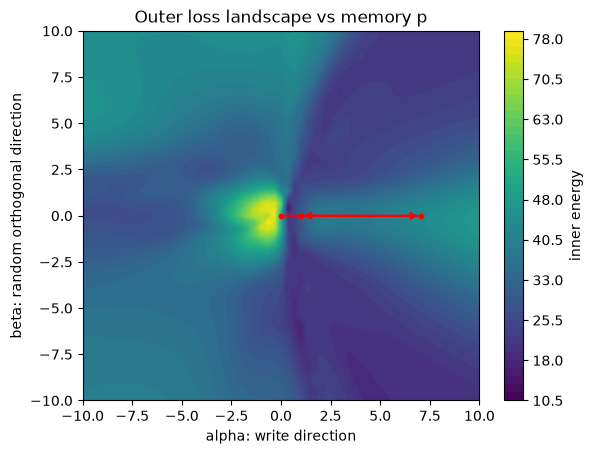

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
cf = ax.contourf(alphas.cpu(), betas.cpu(), Z.T, levels=50)
plt.colorbar(cf, ax=ax, label="inner energy")

ax.set_xlabel("alpha: write direction")
ax.set_ylabel("beta: random orthogonal direction")
ax.set_title("Outer loss landscape vs memory p")

xs, ys = zip(*dots)

ax.plot(
    xs,
    ys,
    marker="o",
    linestyle="none",
    markersize=3,
    color="red",
)

# Draw arrows between consecutive dots
for start, end in zip(dots[:-1], dots[1:]):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={
            "arrowstyle": "->",
            "color": "red",
            "linewidth": 1.5,
        },
        
    )

plt.show()

In [15]:
def get_prefix_mem(state):
    if "mem_batch" in state:
        return state["mem_batch"]
    if "mem" in state:
        return state["mem"]
    raise KeyError("Expected state to contain 'mem_batch' or 'mem'")


def clone_prefix_state_with_mem(state, mem):
    new_state = {}
    for k, v in state.items():
        if torch.is_tensor(v):
            new_state[k] = v.detach().clone()
        else:
            new_state[k] = v
    if "mem_batch" in new_state:
        new_state["mem_batch"] = mem
    elif "mem" in new_state:
        new_state["mem"] = mem
    else:
        new_state["mem_batch"] = mem
    return new_state


def latest_svd_basis(latest_state):
    """
    latest_state memory shape: [B, M, D]

    Returns SVD basis of latest memory:
        M_K = U diag(S) Vh
    """
    memK = get_prefix_mem(latest_state).detach()
    U, S, Vh = torch.linalg.svd(memK, full_matrices=False)
    return U, S, Vh

In [16]:
def state_from_top2_sigma_scales(latest_state, U, S, Vh, sigma1_scale, sigma2_scale):
    S_new = S.clone()

    if S_new.size(-1) >= 1:
        S_new[:, 0] = S[:, 0] * sigma1_scale
    if S_new.size(-1) >= 2:
        S_new[:, 1] = S[:, 1] * sigma2_scale

    mem_new = (U * S_new.unsqueeze(-2)) @ Vh
    return clone_prefix_state_with_mem(latest_state, mem_new)

In [17]:
def build_final_svd_top2_landscape(
    model,
    latest_state,
    backend,
    batch_ctx,
    sigma1_range=(0.0, 2.0),
    sigma2_range=(0.0, 2.0),
    n_sigma1=61,
    n_sigma2=61,
):
    model.eval()

    U, S, Vh = latest_svd_basis(latest_state)
    device = S.device

    sigma1_scales = torch.linspace(*sigma1_range, n_sigma1, device=device)
    sigma2_scales = torch.linspace(*sigma2_range, n_sigma2, device=device)

    Z = torch.empty(n_sigma1, n_sigma2, device="cpu")

    for i, s1 in enumerate(sigma1_scales):
        for j, s2 in enumerate(sigma2_scales):
            state = state_from_top2_sigma_scales(
                latest_state,
                U,
                S,
                Vh,
                sigma1_scale=s1.item(),
                sigma2_scale=s2.item(),
            )
            Z[i, j] = eval_energy_at_state(model, backend, batch_ctx, state)

    return sigma1_scales.cpu(), sigma2_scales.cpu(), Z, (U, S, Vh)

In [18]:
def project_state_onto_latest_top2(state, U, S, Vh, reduce="mean"):
    """
    Coordinates:
        x_t = u_1,K^T M_t v_1,K / sigma_1,K
        y_t = u_2,K^T M_t v_2,K / sigma_2,K

    Returns:
        coords: [2] if reduce='mean', else [B, 2]
        top2_residual_frac: scalar if reduce='mean', else [B]
    """
    M = get_prefix_mem(state).detach()

    u1 = U[:, :, 0]
    u2 = U[:, :, 1]
    v1 = Vh[:, 0, :]
    v2 = Vh[:, 1, :]

    c1 = torch.einsum("bm,bmd,bd->b", u1, M, v1)
    c2 = torch.einsum("bm,bmd,bd->b", u2, M, v2)

    x = c1 / S[:, 0].clamp_min(1e-12)
    y = c2 / S[:, 1].clamp_min(1e-12)

    coords = torch.stack([x, y], dim=-1)

    # How much of M is not explained by the final top-2 modes.
    M_top2 = (
        c1[:, None, None] * u1[:, :, None] * v1[:, None, :]
        + c2[:, None, None] * u2[:, :, None] * v2[:, None, :]
    )
    residual_frac = (
        (M - M_top2).flatten(1).norm(dim=1)
        / M.flatten(1).norm(dim=1).clamp_min(1e-12)
    )

    if reduce == "mean":
        return coords.mean(dim=0), residual_frac.mean()

    if reduce == "none":
        return coords, residual_frac

    raise ValueError("reduce must be 'mean' or 'none'")

def project_memory_trajectory(memory_steps, U, S, Vh, reduce="mean"):
    coords = []
    residuals = []

    for state in memory_steps:
        xy, r = project_state_onto_latest_top2(state, U, S, Vh, reduce=reduce)
        coords.append(xy)
        residuals.append(r)

    return torch.stack(coords), torch.stack(residuals)

In [19]:
def plot_top2_svd_landscape_with_trajectory(
    sigma1_scales,
    sigma2_scales,
    Z,
    coords,
    residuals=None,
    title="Write-Energy Landscape: Final SVD Top-2 Modes",
):
    plt.figure(figsize=(7, 5))

    plt.contourf(
        sigma1_scales,
        sigma2_scales,
        Z.T,
        levels=50,
    )
    plt.colorbar(label="write energy")

    coords_cpu = coords.detach().cpu()

    if residuals is None:
        sizes = 50
    else:
        r = residuals.detach().cpu()
        sizes = 30 + 120 * (r - r.min()) / (r.max() - r.min()).clamp_min(1e-12)

    plt.plot(
        coords_cpu[:, 0],
        coords_cpu[:, 1],
        color="white",
        linewidth=2,
        alpha=0.9,
    )

    plt.scatter(
        coords_cpu[:, 0],
        coords_cpu[:, 1],
        c=torch.arange(coords_cpu.size(0)),
        cmap="viridis",
        s=sizes,
        edgecolor="white",
        linewidth=0.8,
        label="memory steps",
    )

    plt.scatter(
        coords_cpu[0, 0],
        coords_cpu[0, 1],
        color="lime",
        s=90,
        edgecolor="black",
        label="initial",
    )

    plt.scatter(
        coords_cpu[-1, 0],
        coords_cpu[-1, 1],
        color="red",
        s=90,
        edgecolor="black",
        label="latest",
    )

    plt.scatter(
        [1.0],
        [1.0],
        color="black",
        marker="x",
        s=100,
        label="latest SVD point",
    )

    plt.xlabel("projection onto final singular mode 1 / sigma_1,K")
    plt.ylabel("projection onto final singular mode 2 / sigma_2,K")
    plt.title(title)
    plt.legend()
    plt.show()

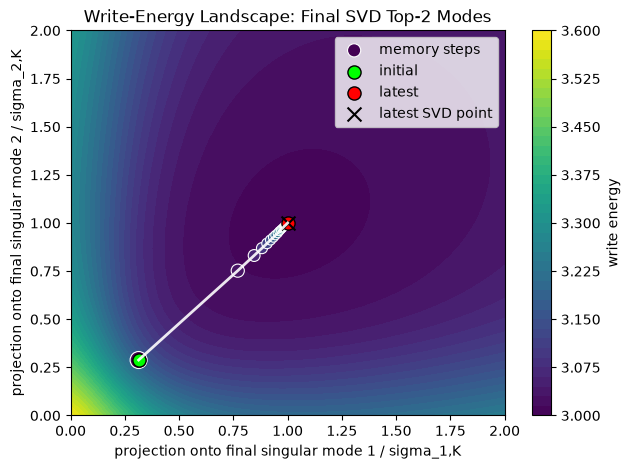

In [21]:
latest_state = memory_history[-1]

sigma1_scales, sigma2_scales, Z, basis = build_final_svd_top2_landscape(
    model=model,
    latest_state=latest_state,
    backend=backend,
    batch_ctx=batch_ctx,
    sigma1_range=(0.0, 2.0),
    sigma2_range=(0.0, 2.0),
    n_sigma1=61,
    n_sigma2=61,
)

U, S, Vh = basis

coords, residuals = project_memory_trajectory(
    memory_history,
    U,
    S,
    Vh,
    reduce="mean",
)

plot_top2_svd_landscape_with_trajectory(
    sigma1_scales,
    sigma2_scales,
    Z,
    coords,
    residuals=residuals,
)

In [20]:
def compute_memory_svd_spectra(
    memory_steps,
    top_k=None,
    reduce_batch="mean",
    sample_idx=0,
    normalize=None,
):
    """
    Args:
        memory_steps: list of memory-state dicts
        top_k: number of singular values to keep
        reduce_batch:
            "mean"   -> average singular values over batch
            "median" -> median over batch
            "sample" -> use one sample from batch
        sample_idx: sample used when reduce_batch="sample"
        normalize:
            None       -> raw singular values
            "sigma1"   -> divide each spectrum by its top singular value
            "fro"      -> divide by Frobenius norm implied by singular values

    Returns:
        spectra: Tensor [num_steps, num_singular_values]
    """
    spectra = []

    for state in memory_steps:
        mem = get_prefix_mem(state).detach().float()  # [B, M, D]
        S = torch.linalg.svdvals(mem)                 # [B, rank]

        if top_k is not None:
            S = S[:, :top_k]

        if normalize == "sigma1":
            S = S / S[:, :1].clamp_min(1e-12)
        elif normalize == "fro":
            S = S / S.pow(2).sum(dim=1, keepdim=True).sqrt().clamp_min(1e-12)
        elif normalize is not None:
            raise ValueError("normalize must be None, 'sigma1', or 'fro'")

        if reduce_batch == "mean":
            s = S.mean(dim=0)
        elif reduce_batch == "median":
            s = S.median(dim=0).values
        elif reduce_batch == "sample":
            s = S[sample_idx]
        else:
            raise ValueError("reduce_batch must be 'mean', 'median', or 'sample'")

        spectra.append(s.cpu())

    return torch.stack(spectra, dim=0)

In [21]:
import numpy as np

def plot_svd(
    spectra,
    title="Memory Singular Value Spectra Over Write Steps",
    xlabel="singular value index",
    ylabel="memory step",
    zlabel="singular value",
    cmap="viridis",
    plot_type="waterfall"
):
    """
    spectra: Tensor or ndarray [num_steps, top_k]
    """
    Z = torch.as_tensor(spectra).detach().cpu().numpy()
    T, K = Z.shape

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")

    if plot_type == "waterfall":
        xs = np.arange(1, K + 1)
        colors = plt.get_cmap(cmap)(np.linspace(0, 1, T))
        for t in range(T):
            ys = np.full(K, t)
            ax.plot(
                xs,
                ys,
                Z[t],
                color=colors[t],
                linewidth=2,
            )
    
    elif plot_type == "surface":
        X, Y = np.meshgrid(np.arange(1, K + 1), np.arange(T))
        
        surf = ax.plot_surface(
            X,
            Y,
            Z,
            cmap=cmap,
            linewidth=0,
            antialiased=True,
            alpha=0.9,
        )
        fig.colorbar(surf, ax=ax, shrink=0.6, label=zlabel)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)

    ax.view_init(elev=25, azim=-55)
    plt.tight_layout()
    plt.show()

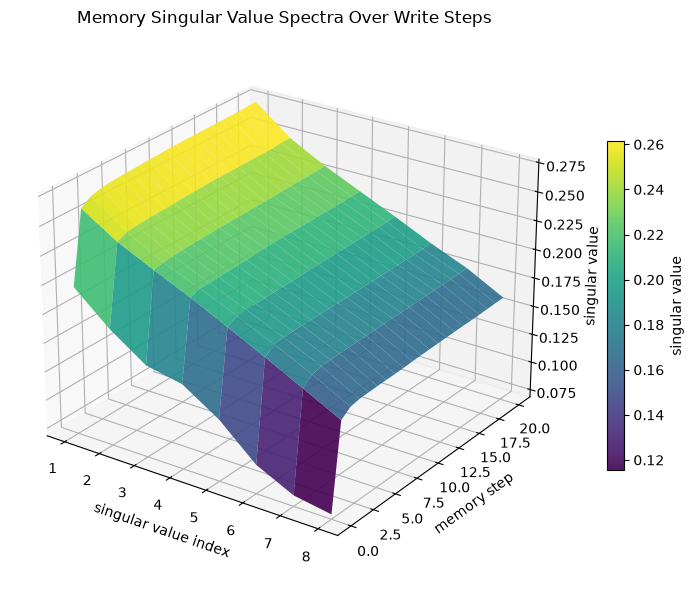

In [24]:
spectra = compute_memory_svd_spectra(
    memory_history,
    top_k=32,
    reduce_batch="mean",
    normalize=None,
)

plot_svd(spectra, plot_type="surface")

In [ ]:
def gradmem_read(self, memory_history, batch_ctx, backend, return_stats=False):
    memory_state = memory_history[-1]
    initial_memory = memory_state_initial = memory_history[0]
    intermediate_memory_states = memory_history[1:-1]
    intermediate_read_active = labels is not None and self.K > 1
    intermediate_read_objective_active = (
        intermediate_read_active and self.intermediate_read_weight > 0.0
    )
    
    read_batch = backend.build_read_inputs(memory_state, batch_ctx)
    read_model_kwargs = read_batch.get('model_kwargs', {})
    log_mem_attn_read = (
        self.attn_implementation == "eager" and self.memory_backend in ("prefix", "kv_cache")
    )
    if log_mem_attn_read:
        read_model_kwargs = dict(read_model_kwargs)
        read_model_kwargs["output_attentions"] = True
    with backend.activation_context(memory_state):
        with self._disable_write_lora():
            read_out = self.model(inputs_embeds=read_batch['inputs_embeds'],
                                    return_dict=True,
                                    **read_model_kwargs)
            logits_q = read_out.logits

    if log_mem_attn_read and read_out.attentions is not None:
        if self.memory_backend == "prefix":
            mem_start = self.n_ctrl_tokens
            mem_end = self.n_ctrl_tokens + self.n_mem_tokens
        else:
            mem_start = 0
            mem_end = self.n_mem_tokens

        layer_ratios = []
        for att in read_out.attentions:
            if att is None:
                continue
            k_len = att.size(-1)
            if not (0 <= mem_start < mem_end <= k_len):
                raise ValueError(
                    "GradMem: Invalid memory attention span on read: "
                    f"backend={self.memory_backend}, mem_start={mem_start}, mem_end={mem_end}, k_len={k_len}"
                )
            layer_ratios.append(att[..., mem_start:mem_end].sum(dim=-1).mean())

    # LoRA/KV-cache memory backends need one seed token to start autoregressive prediction;
    # they cannot predict the very first token from memory alone when query is empty.
    logits_q = logits_q[
        :, read_batch['logits_start']:read_batch['logits_start'] + read_batch['pred_len'], :
    ]

    if not return_stats:
        return logits_q
    
    output = {'predictions': logits_q}
    

    target_loss = self._compute_read_target_loss(output['predictions'], read_batch, labels)

    zero = target_loss.new_tensor(0.0)
    intermediate_read_loss = zero
    if intermediate_memory_states:
        intermediate_depth_losses = []
        energy_objective_active = self.write_objective in ("energy", "energy_with_reconstruction")
        for depth, intermediate_memory_state in enumerate(intermediate_memory_states, start=1):
            intermediate_grad_context = (
                torch.enable_grad() if intermediate_read_objective_active else torch.no_grad()
            )
            with intermediate_grad_context:
                intermediate_read_batch = backend.build_read_inputs(intermediate_memory_state, batch_ctx)
                intermediate_model_kwargs = intermediate_read_batch.get('model_kwargs', {})
                with backend.activation_context(intermediate_memory_state):
                    with self._disable_write_lora():
                        intermediate_read_out = self.model(
                            inputs_embeds=intermediate_read_batch['inputs_embeds'],
                            return_dict=True,
                            **intermediate_model_kwargs,
                        )
                intermediate_predictions = intermediate_read_out.logits[
                    :,
                    intermediate_read_batch['logits_start']:
                    intermediate_read_batch['logits_start'] + intermediate_read_batch['pred_len'],
                    :,
                ]
                depth_target_loss = self._compute_read_target_loss(
                    intermediate_predictions,
                    intermediate_read_batch,
                    labels,
                )

            if intermediate_read_objective_active:
                depth_inner_loss = inner_loss_history[depth - 1].sum() / B
                depth_auxiliary_losses = self._compute_memory_state_auxiliary_losses(
                    backend,
                    intermediate_memory_state,
                    memory_state_initial,
                    batch_ctx,
                    depth_target_loss,
                    initial_memory,
                    depth,
                    energy_loss_history,
                    energy_loss_after_write,
                    memory_alignment_active=memory_alignment_active,
                    orthogonal_loss_active=orthogonal_loss_active,
                    energy_objective_active=energy_objective_active,
                )
                depth_aux_loss = self._combine_depth_auxiliary_losses(
                    inner_loss=depth_inner_loss,
                    rank_loss=depth_auxiliary_losses["rank_loss"],
                    trajectory_loss=depth_auxiliary_losses["trajectory_loss"],
                    anchor_loss=depth_auxiliary_losses["anchor_loss"],
                    memory_alignment_loss=depth_auxiliary_losses["memory_alignment_loss"],
                    orthogonal_loss=depth_auxiliary_losses["orthogonal_loss"],
                )
                intermediate_depth_losses.append(depth_target_loss + depth_aux_loss)
            else:
                intermediate_depth_losses.append(depth_target_loss)

        intermediate_depth_losses = torch.stack(intermediate_depth_losses)
        intermediate_weights = self._intermediate_read_weights(
            self.K,
            device=intermediate_depth_losses.device,
            dtype=intermediate_depth_losses.dtype,
        )
        intermediate_read_loss = (intermediate_weights * intermediate_depth_losses).sum()
    inner_loss_for_outer = inner_loss / B
    loss_stats = {}
    landscape_stats = {}
    energy_objective_active = self.write_objective in ("energy", "energy_with_reconstruction")
    rank_active = energy_objective_active and self.energy_rank_weight > 0.0
    anchor_active = energy_objective_active and self.energy_anchor_weight > 0.0
    trajectory_active = (
        energy_objective_active
        and self.energy_traj_weight > 0.0
        and energy_loss_after_write is not None
    )
    final_auxiliary_losses = self._compute_memory_state_auxiliary_losses(
        backend,
        memory_state,
        memory_state_initial,
        batch_ctx,
        target_loss,
        initial_memory,
        self.K,
        energy_loss_history,
        energy_loss_after_write,
        memory_alignment_active=memory_alignment_active,
        orthogonal_loss_active=orthogonal_loss_active,
        energy_objective_active=energy_objective_active,
    )
    memory_alignment_loss = final_auxiliary_losses["memory_alignment_loss"]
    memory_alignment_cosine = final_auxiliary_losses["memory_alignment_cosine"]
    orthogonal_loss = final_auxiliary_losses["orthogonal_loss"]
    orthogonal_residual_dot = final_auxiliary_losses["orthogonal_residual_dot"]
    rank_loss = final_auxiliary_losses["rank_loss"]
    anchor_loss = final_auxiliary_losses["anchor_loss"]
    traj_loss = final_auxiliary_losses["trajectory_loss"]
    landscape = final_auxiliary_losses["landscape"]
    rank_deranged_loss = zero
    rank_interpolated_loss = zero
    rank_random_loss = zero
    if memory_alignment_cosine is None:
        memory_alignment_cosine = zero
    if orthogonal_residual_dot is None:
        orthogonal_residual_dot = zero
    orthogonal_alpha = (
        F.softplus(self.orthogonal_alpha_raw.float())
        if self.orthogonal_alpha_raw is not None
        else zero.new_tensor(self.lr)
    )

    if landscape is not None:
        energy_positive = landscape["energy_positive"]
        landscape_stats["energy_positive_mean"] = energy_positive.mean()

    if rank_active:
        loss_names = {
            "deranged": "energy_rank_deranged_loss",
            "interpolated": "energy_rank_interpolated_loss",
            "random": "energy_rank_random_loss",
        }
        component_losses = {}
        for name, energy_negative in landscape["negative_energies"].items():
            component_loss = landscape["negative_losses"][name]
            component_losses[loss_names[name]] = component_loss
            landscape_stats[f"energy_negative_{name}_mean"] = energy_negative.mean()
            landscape_stats[f"energy_margin_{name}_mean"] = (energy_negative - energy_positive).mean()
            landscape_stats[f"energy_margin_violation_{name}"] = (
                energy_positive + self.energy_margin > energy_negative
            ).to(dtype=energy_positive.dtype).mean()

        rank_deranged_loss = component_losses.get("energy_rank_deranged_loss", zero)
        rank_interpolated_loss = component_losses.get("energy_rank_interpolated_loss", zero)
        rank_random_loss = component_losses.get("energy_rank_random_loss", zero)

        loss_stats.update({
            "energy_rank_loss": rank_loss,
            "energy_rank_deranged_loss": rank_deranged_loss,
            "energy_rank_interpolated_loss": rank_interpolated_loss,
            "energy_rank_random_loss": rank_random_loss,
        })

    if anchor_active:
        loss_stats["energy_anchor_loss"] = anchor_loss

    if trajectory_active:
        loss_stats["energy_traj_loss"] = traj_loss

    weighted_inner_loss = self.inner_loss_weight * inner_loss_for_outer if self.add_inner_loss_to_outer else zero
    weighted_rank_loss = self.energy_rank_weight * rank_loss if rank_active else zero
    weighted_traj_loss = self.energy_traj_weight * traj_loss if trajectory_active else zero
    weighted_anchor_loss = self.energy_anchor_weight * anchor_loss if anchor_active else zero
    energy_aux_loss = weighted_rank_loss + weighted_traj_loss + weighted_anchor_loss
    weighted_memory_alignment_loss = self.memory_alignment_weight * memory_alignment_loss
    weighted_intermediate_read_loss = self.intermediate_read_weight * intermediate_read_loss
    weighted_orthogonal_loss = self.orthogonal_loss_weight * orthogonal_loss
    auxiliary_loss = self._combine_depth_auxiliary_losses(
        inner_loss=inner_loss_for_outer,
        rank_loss=rank_loss,
        trajectory_loss=traj_loss,
        anchor_loss=anchor_loss,
        memory_alignment_loss=memory_alignment_loss,
        orthogonal_loss=orthogonal_loss,
    )
    outer_loss = target_loss + auxiliary_loss + weighted_intermediate_read_loss

    loss_stats.update({
        "outer_loss": outer_loss,
        "target_loss": target_loss,
        "memory_alignment_loss": memory_alignment_loss,
        "memory_alignment_cosine": memory_alignment_cosine.mean(),
        "orthogonal_loss": orthogonal_loss,
        "orthogonal_residual_dot": orthogonal_residual_dot.mean(),
        "orthogonal_alpha": orthogonal_alpha,
        "intermediate_read_loss": intermediate_read_loss,
    })
    if rank_active or trajectory_active or anchor_active:
        loss_stats["energy_aux_loss"] = energy_aux_loss
    for name, value in {**loss_stats, **landscape_stats}.items():
        output["inner_loop_stats"][name] = value.detach()
    output['loss'] = outer_loss
    return output

In [25]:
def gradmem_read(self, memory_state, batch_ctx, backend):
    read_batch = backend.build_read_inputs(memory_state, batch_ctx)
    read_model_kwargs = read_batch.get('model_kwargs', {})
    log_mem_attn_read = (self.attn_implementation == "eager") and (self.memory_backend in ("prefix", "kv_cache"))
    if log_mem_attn_read:
        read_model_kwargs = dict(read_model_kwargs)
        read_model_kwargs["output_attentions"] = True
    with backend.activation_context(memory_state):
        with self._disable_write_lora():
            read_out = self.model(inputs_embeds=read_batch['inputs_embeds'],
                                    return_dict=True,
                                    **read_model_kwargs)
            logits_q = read_out.logits

    if log_mem_attn_read and read_out.attentions is not None:
        if self.memory_backend == "prefix":
            mem_start = self.n_ctrl_tokens
            mem_end = self.n_ctrl_tokens + self.n_mem_tokens
        else:
            mem_start = 0
            mem_end = self.n_mem_tokens

        layer_ratios = []
        for att in read_out.attentions:
            if att is None:
                continue
            k_len = att.size(-1)
            if not (0 <= mem_start < mem_end <= k_len):
                raise ValueError(
                    "GradMem: Invalid memory attention span on read: "
                    f"backend={self.memory_backend}, mem_start={mem_start}, mem_end={mem_end}, k_len={k_len}"
                )
            layer_ratios.append(att[..., mem_start:mem_end].sum(dim=-1).mean())
        if layer_ratios:
            inner_loop_stats['mem_attn_read'] = torch.stack(layer_ratios).mean().detach()

    logits_q = logits_q[:, read_batch['logits_start']:read_batch['logits_start'] + read_batch['pred_len'], :]
    return logits_q

In [26]:
import numpy as np

def metrics_fn(preds, labels, ignore_token_ids):
    preds = preds[..., :-1].cpu().numpy()
    labels = labels.cpu().numpy()
    mask = (labels != -100)
    for t_id in ignore_token_ids:
        mask &= (labels != t_id)
    masked_predictions = preds[mask]
    masked_labels = labels[mask]
    accuracy = (masked_predictions == masked_labels).mean()
    # get exact_match per-sample accuracy, ignore masked tokens
    # predictions.shape = (batch_size, seq_len)
    exact_match = np.mean([
        np.all(pred[mask[i]] == lab[mask[i]])
        for i, (pred, lab) in enumerate(zip(preds, labels))
        if np.any(mask[i])  # Skip samples that are all masked
    ])
    return {
        "token_accuracy": float(accuracy),
        "exact_match": float(exact_match),
    }

In [13]:
from tqdm import trange
import gc

def get_decay_metrics_for_model(model, valid_data, tokenizer, num_samples, batch_size):
    res_accuracy = np.zeros((model.K,))
    res_exact_match = np.zeros((model.K,))
    inner_loss_stats = np.zeros((model.K,))
    keys_loss_stats = np.zeros((model.K,))
    values_loss_stats = np.zeros((model.K,))

    ignore_token_ids = [tokenizer.convert_tokens_to_ids(t) for t in ['!', '|']]

    for i in trange(0, num_samples, batch_size):
        batch = valid_data[i:min(num_samples, i + batch_size)]
        
        input_ids, labels = collate_fn(batch, tokenizer)
        B = input_ids['context_input_ids'].size(0)
        torch.cuda.empty_cache()
        gc.collect()

        ############################################
        # <--------- BEGIN FAKE FORWARD ---------> #
        ############################################
        with torch.no_grad():

            memory_history, backend, batch_ctx, inner_loop_stats, inner_loss_list, keys_loss_list, values_loss_list = gradmem_write(model, input_ids, labels, return_inner_loss=True, return_kv_losses=True)

            inner_loss_stats += np.array([el.mean().cpu() for el in inner_loss_list]) * B / num_samples
            keys_loss_stats += np.array([el.cpu() for el in keys_loss_list]) * B / num_samples
            values_loss_stats += np.array([el.cpu() for el in values_loss_list]) * B / num_samples

            # try and read from every step of memory updates
            for j, mem_batch_step in enumerate(memory_history[1:]):
                # read for a pair from each segment
                with nn.attention.sdpa_kernel(nn.attention.SDPBackend.MATH):
                    logits = gradmem_read(model, mem_batch_step, batch_ctx, backend)
                
                # compute accuracy of retrieval from each preceding segment per step
                preds = torch.argmax(logits, dim=-1) if logits.dim() > 1 and logits.shape[-1] > 1 else logits
                metrics = metrics_fn(preds, labels, ignore_token_ids)
                res_accuracy[j] += metrics["token_accuracy"] * B / num_samples
                res_exact_match[j] += metrics["exact_match"] * B / num_samples
            
            del memory_history, backend, batch_ctx, inner_loop_stats

    return res_accuracy, res_exact_match, inner_loss_stats, keys_loss_stats, values_loss_stats

In [15]:
acc, em, inner_losses, keys_losses, value_losses = get_decay_metrics_for_model(model, valid_data, tokenizer, 5000, 32)

  0%|          | 0/157 [00:00<?, ?it/s]


ValueError: Expected input batch_size (512) to match target batch_size (16).

In [29]:
a = em
b = inner_losses
c = keys_losses
d = value_losses

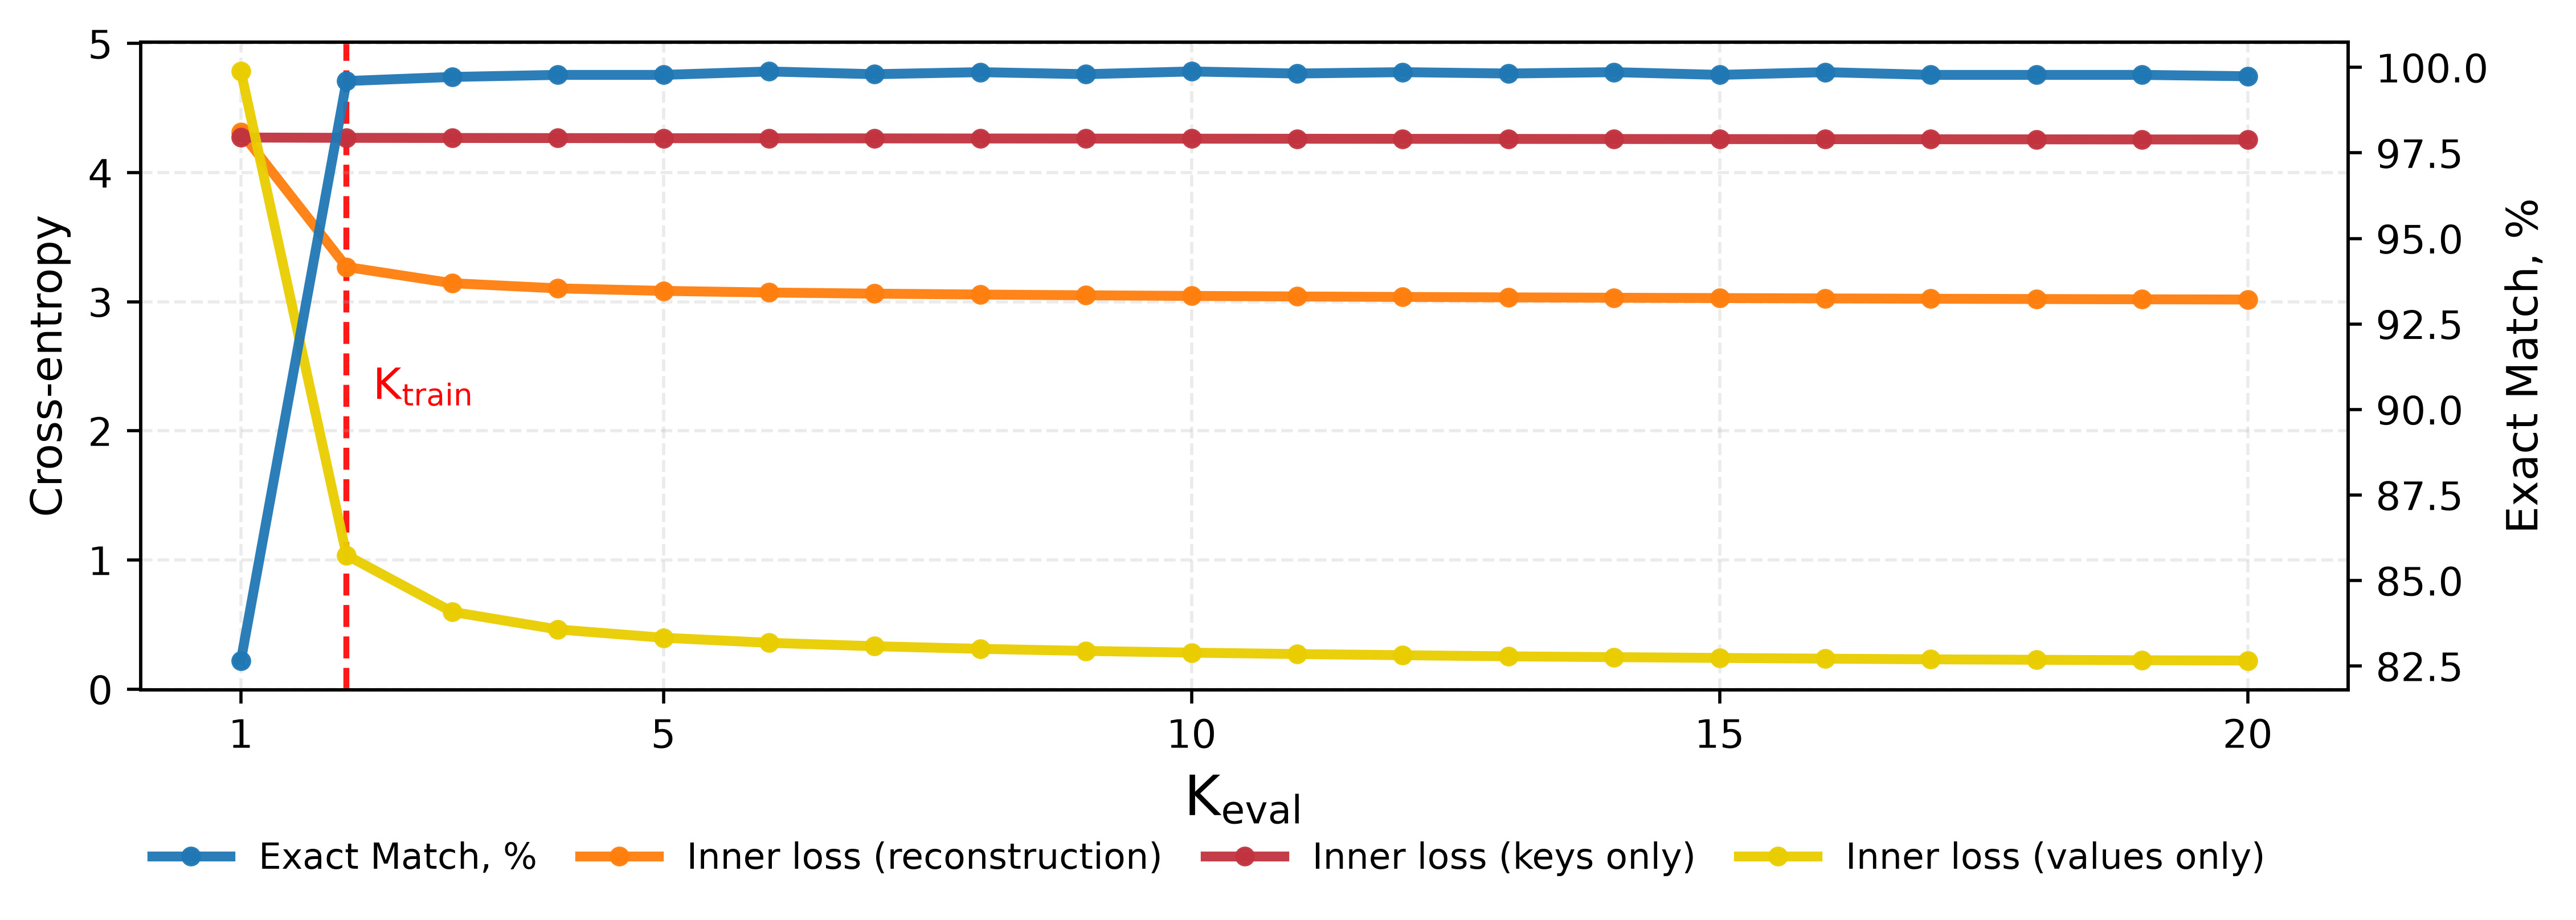

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# If you don't have x, use index
x = np.arange(len(a))

# Colors
c1 = "#1f77b4"
c2 = "#ff7f0e"
c3 = "#c1333f"
c4 = "#e9cd00"

fig, ax1 = plt.subplots(figsize=(10, 3.5), dpi=500)
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

# Left axis: losses
l2, = ax1.plot(
    x, b,
    color=c2,
    linewidth=2.5,
    alpha=0.95,
    label="b",
    marker="o",
    markersize=4,
)

l3, = ax1.plot(
    x, c,
    color=c3,
    linewidth=2.5,
    alpha=0.95,
    label="c",
    marker="o",
    markersize=4,
)

l4, = ax1.plot(
    x, d,
    color=c4,
    linewidth=2.5,
    alpha=0.95,
    label="d",
    marker="o",
    markersize=4,
)

ax1.set_ylabel("Cross-entropy", fontsize=11)

# Subtle grid
ax1.grid(
    True,
    which="major",
    axis="both",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25,
)

# Right axis: exact match
ax2 = ax1.twinx()

l1, = ax2.plot(
    x, np.array(a) * 100,
    color=c1,
    linewidth=2.5,
    alpha=0.95,
    label="a",
    marker="o",
    markersize=4,
)

ax2.set_ylabel("Exact Match, %", fontsize=11)

# X-axis label
ax1.set_xlabel(r"K$_{\mathrm{eval}}$", fontsize=14)

# X-axis tick positions
tick_pos = np.array([0, 4, 9, 14, 19])
tick_pos = tick_pos[tick_pos < len(a)]

ax1.set_xticks(tick_pos)
ax1.set_xticklabels(tick_pos + 1)

# K_train vertical line
k_train_x = 1

ax1.axvline(
    k_train_x,
    linestyle="--",
    linewidth=1.5,
    color="red",
    alpha=0.9,
    zorder=1,
)

ax1.text(
    k_train_x + 0.25,
    0.5,
    r"K$_{\mathrm{train}}$",
    transform=ax1.get_xaxis_transform(),
    ha="left",
    va="top",
    fontsize=11,
    color="red",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.8,
        pad=1.5,
    ),
    zorder=2,
)

# Combined legend underneath both axes
lines = [l1, l2, l3, l4]
labels = [
    "Exact Match, %",
    "Inner loss (reconstruction)",
    "Inner loss (keys only)",
    "Inner loss (values only)",
]

fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    frameon=False,
    fontsize=9,
    handlelength=2.2,
    columnspacing=1.2,
)

# Make room for the legend
fig.subplots_adjust(bottom=0.23)

plt.show()